In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


## Tái sử dụng Embedding và thông tin vị trí từ notebook 01

In [26]:
#Thực hiện việc chuyển đổi từ ngữ thành vector (Token Embedding) và cộng thêm thông tin vị trí (Positional Embedding)
class TransformerEmbeddings(nn.Module):
    def __init__(self, vocab_size, d_model=512, max_len=5000):
        super().__init__()
        #Token Embedding: Mã hóa ý nghĩa
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        #Positional Embedding: Mã hóa vị trí
        self.positional_encoding = nn.Parameter(torch.zeros(1, max_len, d_model))
        
    def forward(self, x):
        # x: (batch_size, seq_len)
        tokens = self.token_embedding(x)
        #Cộng Token Embedding và Positional Embedding 
        return tokens + self.positional_encoding[:, :tokens.size(1), :]


## Cơ chế Self-Attention (1 head)
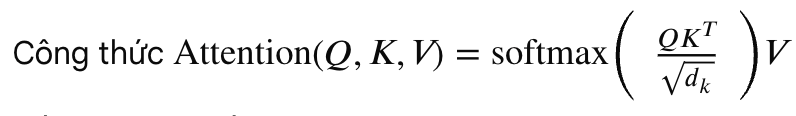

In [27]:
#Self-Attention đơn (1 head)
class SelfAttention(nn.Module):
    def __init__(self, d_model=512):
        super().__init__()
        self.d_model = d_model
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

    def forward(self, x):
        Q = self.w_q(x)
        K = self.w_k(x)
        V = self.w_v(x)

        #Tích vô hướng (Q x Kᵀ) / √d_k để Scale
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_model)

        #Softmax để lấy trọng số chú ý (attention weights)
        attn = F.softmax(scores, dim=-1)

        #Nhân trọng số với Value để ra Context Vector
        context = torch.matmul(attn, V)
        return context, attn


In [28]:
sentence = "You are a beautiful girl"
tokens = sentence.split()
vocab = {"You": 101, "are": 102, "a": 103, "beautiful": 104, "girl": 105}
input_ids = torch.tensor([[vocab[w] for w in tokens]])

#Dùng lại TransformerEmbeddings
emb_layer = TransformerEmbeddings(vocab_size=1000, d_model=512)
input_vectors = emb_layer(input_ids) # Shape: (1, 5, 512)

self_attn = SelfAttention(d_model=512)
context, attn_weights = self_attn(input_vectors)
attn_matrix = attn_weights[0].detach().numpy()

print("SELF-ATTENTION")
print(f"Input: '{sentence}' ({len(tokens)} từ)")

header = "        " + "".join(f"{t:>12}" for t in tokens)

print("\nAttention Matrix:")
print(header)

for i, tok in enumerate(tokens):
    row = "".join(
        f"{attn_matrix[i][j]:>12.3f}"
        for j in range(len(tokens))
    )
    print(f"{tok:<8}{row}")

print("\nAttention Weights Shape:")
print(list(attn_weights.shape))

print("\nAttention Output Shape:")
print(list(context.shape))

# Lấy vector của từ "girl"
girl_before = input_vectors[0, 4, :10].detach().numpy()
girl_after = context[0, 4, :10].detach().numpy()

print("\nVector của 'girl' trước Attention (10 giá trị đầu):")
print(girl_before)

print("\nVector của 'girl' sau Attention (10 giá trị đầu):")
print(girl_after)

SELF-ATTENTION
Input: 'You are a beautiful girl' (5 từ)

Attention Matrix:
                 You         are           a   beautiful        girl
You            0.170       0.207       0.173       0.134       0.316
are            0.226       0.251       0.192       0.155       0.176
a              0.252       0.279       0.163       0.088       0.217
beautiful       0.248       0.289       0.149       0.139       0.176
girl           0.316       0.120       0.198       0.132       0.234

Attention Weights Shape:
[1, 5, 5]

Attention Output Shape:
[1, 5, 512]

Vector của 'girl' trước Attention (10 giá trị đầu):
[ 0.5439688  -1.0182413  -0.33737177 -0.19075733  0.7849798  -2.0967581
 -0.12275221  0.21990415 -0.15832388  0.41496393]

Vector của 'girl' sau Attention (10 giá trị đầu):
[-0.14646131 -0.26982054  0.06262238  0.01734382 -0.04262166 -0.4380017
  0.36629498 -0.38164     0.01808823 -0.12837636]


## Cơ chế Multi-Head Self-Attention
Chia Q, K, V thành nhiều head song song, tính Self-Attention riêng từng head, rồi Concatenate + Linear (Wᵒ).

In [29]:
#Ví dụ linh hồn của Transformer: Multi-Head Attention với cơ chế Query, Key, Value
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=512, n_heads=8):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.d_k = d_model // n_heads # 64 chiều mỗi đầu
        self.n_heads = n_heads
        
        #Các ma trận trọng số WQ, WK, WV
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        #Tạo Q, K, V và chia thành n_heads
        Q = self.w_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        #Tính Scores bằng tích vô hướng và Scaling
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        #Softmax để lấy trọng số chú ý
        attn = F.softmax(scores, dim=-1)
        
        #Nhân với Value và gộp các đầu lại
        context = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.w_o(context)


In [30]:
sentence = "You are a beautiful girl"
tokens = sentence.split()
vocab = {"You": 101, "are": 102, "a": 103, "beautiful": 104, "girl": 105}
input_ids = torch.tensor([[vocab[w] for w in tokens]])

#Dùng lại TransformerEmbeddings
emb_layer = TransformerEmbeddings(vocab_size=1000, d_model=512)
input_vectors = emb_layer(input_ids) # Shape: (1, 5, 512)

mha = MultiHeadAttention(d_model=512, n_heads=8)
context_vectors = mha(input_vectors, input_vectors, input_vectors)


print("MULTI-HEAD SELF-ATTENTION")
print(f"Input: '{sentence}' ({len(tokens)} từ)")

print("\nCấu hình:")
print(f"- d_model: 512")
print(f"- số heads: 8")
print(f"- mỗi head: {512 // 8} chiều")

print("\nInput Shape:")
print(list(input_vectors.shape))

print("\nOutput Shape:")
print(list(context_vectors.shape))


# So sánh vector của "girl"
girl_before = input_vectors[0, 4, :10].detach().numpy()
girl_after = context_vectors[0, 4, :10].detach().numpy()

print("\nVector 'girl' trước Multi-Head Attention:")
print(girl_before)

print("\nVector 'girl' sau Multi-Head Attention:")
print(girl_after)



MULTI-HEAD SELF-ATTENTION
Input: 'You are a beautiful girl' (5 từ)

Cấu hình:
- d_model: 512
- số heads: 8
- mỗi head: 64 chiều

Input Shape:
[1, 5, 512]

Output Shape:
[1, 5, 512]

Vector 'girl' trước Multi-Head Attention:
[-0.43031126  0.850076    1.0849417  -0.42837197 -0.04254517  0.04533003
  0.05328871  0.1670929  -0.966387   -0.01770882]

Vector 'girl' sau Multi-Head Attention:
[-0.38423902 -0.41722807  0.16458559 -0.0824378   0.06547187 -0.00269417
  0.1035217   0.13234052  0.0129974   0.04467303]
